In [1]:
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings 
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model="gpt-5-mini")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [4]:
pdf_path = "Stock_Market_Performance_2024.pdf"

if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"PDF file not found: {pdf_path}")

pdf_loader = PyPDFLoader(pdf_path)

try: 
    pages = pdf_loader.load()
    print(f"PDF file loaded: {len(pages)} pages") 
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

PDF file loaded: 9 pages


In [5]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

split_pages = text_splitter.split_documents(pages)

# for i, chunk in enumerate(split_pages):
#     print(f"\nDocument {i + 1}:\n{chunk.page_content}")

In [6]:
os.getcwd()

persist_directory = "/Volumes/VTG/Dev/LangGraph tutorial"
collection_name = "stock_market"

In [7]:
vectorstore = Chroma.from_documents(
    documents=split_pages,
    embedding=embeddings,
    persist_directory=persist_directory,
    collection_name=collection_name
)

In [8]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

In [9]:
@tool
def retriever_tool(query: str) -> str:
    """
    Tool node that executes document retrieval 
    """

    docs = retriever.invoke(query)

    if not docs:
        return "There's no valid documents" #### It MUST return and exit the function right away when docs not found!!

    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i + 1}:\n{doc.page_content}")

    return "\n\n".join(results)

In [10]:
tools = [retriever_tool]
llm = llm.bind_tools(tools)

In [11]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [12]:
system_message = SystemMessage(
    content="""
    You MUST use the retriever tool when the question relates to stock market data in 2024.
    Only answer from general knowledge if the question is clearly unrelated.
    Always cite the retrieved documents.
    """.strip()
)

In [21]:
def llm_agent(state: AgentState) -> AgentState:
    """
    Execute LLM calls and control the LLM flow
    """

    # print("DEBUG STATE1: ", state)
    
    all_messages = [system_message] + list(state["messages"])
    response = llm.invoke(all_messages)
    
    return {"messages": [response]}

In [22]:
def should_continue(state: AgentState) -> bool:
    """
    Decide whether the graph execution should continue or not. 
    The determination is made by whether the AIMessage(last message) contains tool_calls for continuation.
    """

    if not state["messages"]:
        return False
    
    last_message = state["messages"][-1]

    return hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0

In [23]:
tool_dict = {tool.name: tool for tool in tools}

In [24]:
def take_action(state: AgentState) -> AgentState:
    """
    Execute tool call validation and trigger a call to the tool fucntion
    """
    # Make sure to get the last message safely first 
    # to avoid the runtime error in case of the tool_calls attr not found

    last_message = state.get("messages", [])[-1] if state.get("messages") else None

    # in case of no tool calls - return empty messages as a safer fallback
    if not last_message or not hasattr(last_message, "tool_calls") or not last_message.tool_calls:
        return {"messages": []} 

    results = []

    for tc in last_message.tool_calls:
        tool_name = tc["name"]
        tool_call_id = tc["id"]
        query = tc.get("args", {}).get("query", "")

        print(f"Calling Tool: {tool_name} with query: {query}")

        # Validate tool
        if tool_name not in tool_dict:
            result = f"Invalid tool name: {tool_name}"
        else:
            try:
                result = tool_dict[tool_name].invoke(query)
            except Exception as e:
                result = f"Tool execution failed: {str(e)}"

        results.append(
            ToolMessage(
                tool_call_id=tool_call_id,
                name=tool_name, 
                content=str(result)
            )
        )

    print("Tool execution complete. Back to the LLM")

    return {"messages": results}
    

In [25]:
graph = StateGraph(AgentState)

graph.add_node("llm_agent", llm_agent)
graph.add_node("RAG_agent", take_action)

graph.add_edge(START, "llm_agent")
graph.add_conditional_edges(
    "llm_agent",
    should_continue,
    {
        True: "RAG_agent",
        False: END
    }
)
graph.add_edge("RAG_agent", "llm_agent")

rag_agent = graph.compile()

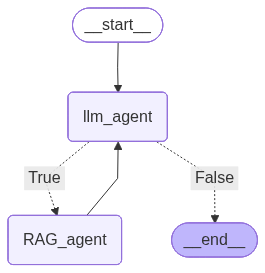

In [26]:
rag_agent

In [27]:
def running_agent():
    print("\n===== RAG AGENT =====")
    while True:
        print("AI: What may I help you with?")
        user_input = input()

        if user_input.lower() in ["exit", "bye"]:
            break
            
        human_message = [HumanMessage(content=user_input)]
        result = rag_agent.invoke({"messages": human_message})

        print("\n===== ANSWER =====")
        print("AI: ", result["messages"][-1].content)    

In [ ]:
if __name__ == "__main__":
    running_agent()


===== RAG AGENT =====
AI: What may I help you with?


 hi



===== ANSWER =====
AI:  Hi — how can I help you today?
AI: What may I help you with?


 stock market in 2024


Calling Tool: retriever_tool with query: 2024 stock market overview S&P 500 year-to-date 2024 performance Reuters March 2024 U.S. markets 2024 outlook Federal Reserve interest rates inflation 2024 market themes tech AI energy banking turmoil 2024 news
Tool execution complete. Back to the LLM
